#### 260112: The general script to summarize all results of different experiments for Boosted Rules (Boomer)!

In [1]:
##### Containing all packages used in the notebook! #####
import json
import os
import numpy as np
import re
import pandas as pd
import builtins
from collections import Counter, OrderedDict

##
import matplotlib.pyplot as plt
from itertools import accumulate

In [2]:
#### General functions used in Table generation of different experiments! ####
def get_df_infos(df, method, max_depth, n_estimator, dataset=None, wd=None):
    '''
        updated in 260112 => add the wd, while wd must accompany with valid dataset
    '''
    if not dataset is None:
        assert (method in set(df['method'])) and (max_depth in set(df['max_depth'])) \
            and (n_estimator in set(df['n_estimator']) and dataset in set(df['dataset']))
        if not wd is None:
            assert (wd in set(df['wd']))
            df_infos = df[(df['method'] == method) & (df['max_depth'] == max_depth) \
                & (df['n_estimator'] == n_estimator) & (df['dataset'] == dataset) & (df['wd'] == wd)]
        else:
            df_infos = df[(df['method'] == method) & (df['max_depth'] == max_depth) \
                & (df['n_estimator'] == n_estimator) & (df['dataset'] == dataset)]
        # assert df_infos.shape[0] == 1
    else:
        assert (method in set(df['method'])) and (max_depth in set(df['max_depth'])) \
            and (n_estimator in set(df['n_estimator']))
        df_infos = df[(df['method'] == method) & (df['max_depth'] == max_depth) \
                & (df['n_estimator'] == n_estimator)]
    return df_infos
    
def value2str(v):
    # considering the 0.00 cases (< 0.01) => especially in seconds
    if isinstance(v, np.float64):
        return f'{v:.2f}' if v > 0.01 else '$<$'
    elif isinstance(v, np.int64):
        return str(v)
    else:
        return v

def value2str_dp3(v):
    # decimal place 3
    if isinstance(v, np.float64):
        return f'{v:.3f}'
    elif isinstance(v, np.int64):
        return str(v)
    else:
        return v

def str_with_bold_value(df1, df2, col_names, maxs):

    assert len(col_names) == len(maxs)
    better_infos = []
    str_row_1, str_row_2 = '', ''
    # 251002: add the value #wins (if equal, both are #wins + 1)
    wins_d1, wins_d2 = {}, {}
    for i in range(len(col_names)):
        wins_d1[col_names[i]] = 0
        wins_d2[col_names[i]] = 0
        if df1.iloc[-1][col_names[i]] == df2.iloc[-1][col_names[i]]:
            better_infos.append(False)
            str_row_1 += '\\textbf{' + value2str(df1.iloc[-1][col_names[i]]) + '} & ' 
            wins_d1[col_names[i]] += 1
            wins_d2[col_names[i]] += 1
        elif (df1.iloc[-1][col_names[i]] > df2.iloc[-1][col_names[i]]) ^ maxs[i]:
            better_infos.append(False)
            str_row_1 += value2str(df1.iloc[-1][col_names[i]]) + ' & '
            wins_d2[col_names[i]] += 1
        else:
            better_infos.append(True)
            str_row_1 += '\\textbf{' + value2str(df1.iloc[-1][col_names[i]]) + '} & '
            wins_d1[col_names[i]] += 1
        
    for i in range(len(col_names)):
        str_row_2 += value2str(df2.iloc[-1][col_names[i]]) + ' & ' if better_infos[i] else '\\textbf{' + value2str(df2.iloc[-1][col_names[i]]) + '} & '
    # str_row_2 += value2str(df2.iloc[-1][col_names[-1]]) + ' \\\\' if better_infos[-1] else '\\textbf{' + value2str(df2.iloc[-1][col_names[-1]]) + '}'
    return str_row_1, str_row_2, wins_d1, wins_d2

def str_with_bold_value_dp3(df1, df2, col_names, maxs):

    assert len(col_names) == len(maxs)
    better_infos = []
    str_row_1, str_row_2 = '', ''
    # 251002: add the value #wins (if equal, both are #wins + 1)
    wins_d1, wins_d2 = {}, {}
    for i in range(len(col_names)):
        wins_d1[col_names[i]] = 0
        wins_d2[col_names[i]] = 0
        if df1.iloc[-1][col_names[i]] == df2.iloc[-1][col_names[i]]:
            better_infos.append(False)
            str_row_1 += '\\textbf{' + value2str_dp3(df1.iloc[-1][col_names[i]]) + '} & ' 
            wins_d1[col_names[i]] += 1
            wins_d2[col_names[i]] += 1
        elif (df1.iloc[-1][col_names[i]] > df2.iloc[-1][col_names[i]]) ^ maxs[i]:
            better_infos.append(False)
            str_row_1 += value2str_dp3(df1.iloc[-1][col_names[i]]) + ' & '
            wins_d2[col_names[i]] += 1
        else:
            better_infos.append(True)
            str_row_1 += '\\textbf{' + value2str_dp3(df1.iloc[-1][col_names[i]]) + '} & '
            wins_d1[col_names[i]] += 1
        
    for i in range(len(col_names)):
        str_row_2 += value2str_dp3(df2.iloc[-1][col_names[i]]) + ' & ' if better_infos[i] else '\\textbf{' + value2str_dp3(df2.iloc[-1][col_names[i]]) + '} & '
    return str_row_1, str_row_2, wins_d1, wins_d2

def deal_wins(win_all, win_specific):
    if win_all is None:
        win_all = Counter(win_specific)
    else:
        win_all = win_all + Counter(win_specific)
    return win_all

def wins2str(wins, keys_given):
    wins2str = ''
    for i in range(len(keys_given) - 1):
        wins2str += str(wins[keys_given[i]]) + ' & '
    wins2str += str(wins[keys_given[-1]]) + ' '
    return wins2str

def str_show_cols(df, col_names):
    str_row = ''
    for i in range(len(col_names) - 1):
        str_row += value2str(df.iloc[-1][col_names[i]]) + ' & '
    str_row += value2str(df.iloc[-1][col_names[-1]]) + '\\\\' 
    return str_row

#### Exp 1: Prediction Quality between XGBoost and Boomer!

- Run the script of "Exp_Boomer.ipynb" and "Exp_XGBoost.ipynb" to train different Boosting models, and all results are stored in corresponding JSON files.
- The prediction quality results are saved in folder of Exp1(for all tabular benchmarks) and Exp3 (for MNIST)

- Boomer prediction results (containing drule) with different weights digits => Exp1/temp_boomers_251125
- XGBoost prediction results => Exp1/temp_xgboost_251022

In [ ]:
# Step 1: Transform the results of JSON format into the dataframe

# read XGBoost and BOOMER reults in JSON format
df_xgboost_acc = pd.read_json('./Exp1_BoostRules_XGBoost/result_xgboost_251022.json')
df_boomers_acc = pd.read_json('./Exp1_BoostRules_XGBoost/result_boomers_251125.json')

df_xgboost_acc['method'] = 'xgboost'
df_boomers_acc['method'] = 'boomer'
# wdigit = -1 => the original version without the reduction in weight digit
df_boomers_acc.rename(columns={'wdigit': 'wd'}, inplace=True)
df_xgboost_acc['wd'] = -1
df_boomers_acc= df_boomers_acc.where(pd.notnull(df_boomers_acc), -1)

datasets = sorted(set(df_xgboost_acc['dataset']))
# concat the two results dataframes into one
df_xgboost_boomer_acc = pd.concat([df_xgboost_acc, df_boomers_acc])


##### Preparing the Table summarizing the prediction results of Boomer (different wds) and XGBoost

*Take care: Here are all results of tabular benchmarks!!*

In [54]:
def ptable_boomer_xgboost_separate(df, out_base_path='latex_separ'):
    '''
        260126: prepare the entire summary boomer and xgboost 
        1 + 2 cols (max_depth, num) => Boomer orig (path, train, test) | Boomer wd1 (train/test) | Boomer wd2 => xgboost (path, train, test)
        comparing direct Boomer (orig) and xgboost in path/train/test
    '''
    if not os.path.exists(out_base_path):
        os.mkdir(out_base_path)
    datasets_infos = sorted(set(df['dataset']))
    cols_selected = ['num_identical_path', 'train_acc', 'test_acc']

    for d_info in datasets_infos:
        out_path = os.path.join(out_base_path, d_info.replace('\n', '') + '_separ.tex')
        # 1st col (m_depth) => 2nd col (num_estimator) => Boomer (train/test) for each w_digit
        num_estimators = sorted(set(df['n_estimator']))
        wdigits = sorted(set(df['wd']))
        win_b_all, win_x_all = None, None

        with builtins.open(out_path, 'w') as f:
            for m_depth in sorted(set(df['max_depth'])):
                # prepare each multirow cell
                f.write('\\multirow{' + str(len(num_estimators)) + '}{*}{' + str(m_depth) + '}\n')
                for n in num_estimators:
                    f.write('& ' + str(n) + ' & ')
                    str_row = ''
                    df_b_orig_infos = get_df_infos(df, 'boomer', m_depth, n, d_info, wd=-1)
                    df_x_orig_infos = get_df_infos(df, 'xgboost', m_depth, n, d_info, wd=-1)

                    str_1, str_2, win_b, win_x = str_with_bold_value_dp3(df_b_orig_infos, df_x_orig_infos, cols_selected, [False, True, True])
                    win_b_all = deal_wins(win_b_all, win_b)
                    win_x_all = deal_wins(win_x_all, win_x)

                    str_row += str_1
                    for wd in wdigits:
                        df_b_wd_infos = get_df_infos(df, 'boomer', m_depth, n, d_info, wd=wd)
                        for col in cols_selected[1:]:
                            # presenting the differenc to the orig instead of value
                            if wd != -1.0:
                                str_row += value2str_dp3(df_b_wd_infos.iloc[-1][col] - df_b_orig_infos.iloc[-1][col]) + ' & '
                    str_row += str_2
                    f.write(str_row[:-2] + '\\\\\n')
                f.write('\\hline \n')
            # dealing the last line of wins
            str_ands = '& / ' * ((len(wdigits) - 1) * (len(cols_selected) -1))
            f.write('\\#WINS & / & ' + wins2str(win_b_all, cols_selected) + str_ands + '& ' +  wins2str(win_x_all, cols_selected) + '\\\\ \\hline')

In [ ]:
# generating the tables of different tabular benchmarks
ptable_boomer_xgboost_separate(df_xgboost_boomer_acc, './Exp1_BoostRules_XGBoost/latex_separ')

#### Exp 2: Efficency in Extracting AXps from Models of Boomer (MaxSAT/SAT) and XGBoost (MaxSAT)!

- The running time results are saved in folder of Exp2 (for all tabular benchmarks) and Exp3 (for MINST)


In [3]:

# Step 1: summarize all raw log files information into the JSON format
# Information includes Encoding (#Vars, #Clauses), Runing time (max, min, avg)
# Two kind of json file => one contains all details for each instance, one is the summary
def extract_folder_info(folder, info_dict):
    r = re.compile('([a-zA-Z]+)([0-9]+)')
    folder_info = {}

    for info in folder.split('/')[-1].split('_')[1:]:
        info_k, info_v = r.match(info).groups()
        folder_info[info_dict[info_k]] = info_v
    return folder_info

def extract_summary_detail_json(results_bpath, info_dict, timeout=1800.0):
    summary_json_path = os.path.join(results_bpath, 'summary.json')
    detail_json_path = os.path.join(results_bpath, 'detail.json')
    if os.path.exists(summary_json_path):
        os.remove(summary_json_path)
    if os.path.exists(detail_json_path):
        os.remove(detail_json_path)

    sub_folders = sorted([f.path for f in os.scandir(results_bpath) if f.is_dir()])
    res_summary_json, res_detail_json = [], []

    for sub_f in sub_folders:
        # get the corresponding infos in the name of sub_f
        sub_f_info_dict = extract_folder_info(sub_f, info_dict[0])

        files = sorted([f.path for f in os.scandir(sub_f) if f.is_file() and f.path.endswith('.log')])

        for file in files:
            curr_res_detail_json_i, curr_res_t_allowed = [], []
            res_summary_dict = sub_f_info_dict.copy()
            res_summary_dict[info_dict[-1]] = file.split('/')[-1].split('.')[0]
            res_detail_dict = res_summary_dict.copy()

            with open(file, 'r') as f:
                lines = [l.strip('\n') for l in f.readlines() if l.strip()]
                for l in lines:
                    k, v = l.split(':')
                    # 251210: change for more information
                    infos = ['vars', 'clauses', 'max time', 'min time', 'avg time', 'avg calls', \
                             'avg vars', 'avg cos', 'avg cps', 'num time']
                    if k.rstrip(' ') in infos:
                        res_summary_dict[k.rstrip(' ')] = v.strip()
                    else:
                        res_detail_dict[k] = v.strip()

                    if k == 'mem' or k == 'axp':
                        # avoid the instances duplicated 
                        # 260306: add the check of a timeout for an instance
                        if not 't' in res_detail_dict.keys():
                            continue
                        if (not res_detail_dict['i'] in curr_res_detail_json_i) and (float(res_detail_dict['t']) < timeout):
                            res_detail_json.append(res_detail_dict.copy())
                            curr_res_detail_json_i.append(res_detail_dict.copy()['i'])
                            curr_res_t_allowed.append(float(res_detail_dict['t']))
                            res_detail_dict['t'] = timeout + 1.0
            res_summary_dict['n_instance'] = len(curr_res_detail_json_i)
            # 260306: update the time
            if 'num time' in res_summary_dict.keys():
                assert int(res_summary_dict['num time']) == len(curr_res_t_allowed)
            else:
                res_summary_dict['num time'] = len(curr_res_t_allowed)
            res_summary_dict['max time'] = max(curr_res_t_allowed)
            res_summary_dict['min time'] = min(curr_res_t_allowed)
            res_summary_dict['avg time'] = sum(curr_res_t_allowed) / len(curr_res_t_allowed)
            res_summary_json.append(res_summary_dict)

    with open(summary_json_path, 'w') as f:
        json.dump(res_summary_json, f, indent=2)
    print("Summary Json for " + results_bpath + " is stored in " + summary_json_path)
    with open(detail_json_path, 'w') as f:
        json.dump(res_detail_json, f, indent=2)
    print("Deatiled for " + results_bpath + " is stored in " + detail_json_path)


##### Preparing the summary/detail JSON files, and the dataframes (XGBoost v.s. Boomer-MaxSAT)

In [22]:
results_axp_boomer = './Exp2_Explanation_BoostRules/results_AXp_boomer_251125'
results_axp_xgboost = './Exp2_Explanation_BoostRules/results_AXp_xgboost_250925'
info_dict = [{'md': 'max_depth', 'num': 'n_estimator'}, 'dataset']

# call the function to generate the two json files
extract_summary_detail_json(results_axp_boomer, info_dict)
extract_summary_detail_json(results_axp_xgboost, info_dict)

#######################
# Step 2: Transform the results in JSON format into pandas format
df_xgboost_axp_s = pd.read_json(os.path.join(results_axp_xgboost, 'summary.json'))
df_boomers_axp_s = pd.read_json(os.path.join(results_axp_boomer, 'summary.json'))

df_xgboost_axp_s['method'] = 'xgboost'
df_boomers_axp_s['method'] = 'boomer'
df_xgboost_axp_s = df_xgboost_axp_s.rename(columns={'vars': 'avg vars', 'clauses': 'avg cps'})

df_xgboost_boomers_axp_s = pd.concat([df_xgboost_axp_s, df_boomers_axp_s])
# add_info_format = lambda r: r['dataset'] + '(' + str(r['n_instance']) + ')'
# df_xgboost_boomers_axp['dataset'] = df_xgboost_boomers_axp.apply(add_info_format, axis='columns')

### the details dataframe
df_xgboost_axp_d = pd.read_json(os.path.join(results_axp_xgboost, 'detail.json'))
df_boomers_axp_d = pd.read_json(os.path.join(results_axp_boomer, 'detail.json'))

df_xgboost_axp_d['method'] = 'xgboost'
df_boomers_axp_d['method'] = 'boomer'
df_xgboost_axp_d = df_xgboost_axp_d.rename(columns={'vars': 'avg vars', 'clauses': 'avg cps'})

df_xgboost_boomers_axp_d = pd.concat([df_xgboost_axp_d, df_boomers_axp_d])


Summary Json for ./Exp2_Explanation_BoostRules/results_AXp_boomer_251125 is stored in ./Exp2_Explanation_BoostRules/results_AXp_boomer_251125/summary.json
Deatiled for ./Exp2_Explanation_BoostRules/results_AXp_boomer_251125 is stored in ./Exp2_Explanation_BoostRules/results_AXp_boomer_251125/detail.json
Summary Json for ./Exp2_Explanation_BoostRules/results_AXp_xgboost_250925 is stored in ./Exp2_Explanation_BoostRules/results_AXp_xgboost_250925/summary.json
Deatiled for ./Exp2_Explanation_BoostRules/results_AXp_xgboost_250925 is stored in ./Exp2_Explanation_BoostRules/results_AXp_xgboost_250925/detail.json


##### Preparing the summary/detail JSON files, and the dataframes (Boomer-SAT v.s. Boomer-MaxSAT) with different weight digits

In [25]:
# 260112: considering the results with different weight digits + pb_encoding + encoding
results_boomer_sat = './Exp2_Explanation_BoostRules/results_AXp_boomer_sat'
results_boomer_mx = './Exp2_Explanation_BoostRules/results_AXp_boomer_mx'
info_dict = [{'md': 'max_depth', 'num': 'n_estimator', 'wd': 'wd', 'pb': 'pb'}, 'dataset']
# call function to generate the json files
extract_summary_detail_json(results_boomer_sat, info_dict)
extract_summary_detail_json(results_boomer_mx, info_dict)

#######################
# Step 2: Transform the results in JSON format into pandas format
df_boomers_mx= pd.read_json(os.path.join(results_boomer_mx, 'summary.json'))
df_boomers_sat = pd.read_json(os.path.join(results_boomer_sat, 'summary.json'))

df_boomers_mx['method'] = 'mx'
df_boomers_sat['method'] = 'sat'

df_boomers = pd.concat([df_boomers_mx, df_boomers_sat])

##### the detail dataframe
df_boomers_mx_axp_d= pd.read_json(os.path.join(results_boomer_mx, 'detail.json'))
df_boomers_sat_axp_d = pd.read_json(os.path.join(results_boomer_sat, 'detail.json'))

df_boomers_mx_axp_d['method'] = 'mx'
df_boomers_sat_axp_d['method'] = 'sat'
df_boomers_axp_d = pd.concat([df_boomers_mx_axp_d, df_boomers_sat_axp_d])


Summary Json for ./Exp2_Explanation_BoostRules/results_AXp_boomer_sat is stored in ./Exp2_Explanation_BoostRules/results_AXp_boomer_sat/summary.json
Deatiled for ./Exp2_Explanation_BoostRules/results_AXp_boomer_sat is stored in ./Exp2_Explanation_BoostRules/results_AXp_boomer_sat/detail.json
Summary Json for ./Exp2_Explanation_BoostRules/results_AXp_boomer_mx is stored in ./Exp2_Explanation_BoostRules/results_AXp_boomer_mx/summary.json
Deatiled for ./Exp2_Explanation_BoostRules/results_AXp_boomer_mx is stored in ./Exp2_Explanation_BoostRules/results_AXp_boomer_mx/detail.json


##### Preparing Tables (XGBoost v.s. Boomer-MaxSAT): 2 different types of Tables

- T1: One Table corresponds to all benchmarks with a specific number of estimators of methods to explain 200 instances, which contains the following columns:
    - (Vars, Clauses): Number of the variables used, and the clauses used
    - (max, min, avg): The maximum, minimum, and average execution time to explain an instance
    - avg\_call: The average number of calls for inner SAT oracles.
- T2: One Table corresponds to a specific benchmark with all different maximum depths and number of estimators of methods to explain 200 instances.

In [ ]:
## 2511: Code preparing tables comparing Boomers and XGBoost
def prepare_table_by_bench_separ(df, out_base_path='latex_separ'):
    '''
        Not changed!!
    '''
    if not os.path.exists(out_base_path):
        os.mkdir(out_base_path)
    datasets_infos = sorted(set(df['dataset']))
    cols_selected = ['train_acc', 'test_acc', 'num_identical_path']

    for d_info in datasets_infos:
        out_path = os.path.join(out_base_path, d_info.replace('\n', '') + '_separ.tex')
        win_b_all, win_x_all = None, None
        # 1st col (m_depth) => 2nd col (num_estimator) => Boomer(train/test/num_identical_path), XGBoost
        num_estimators = sorted(set(df['n_estimator']))
        with builtins.open(out_path, 'w') as f:
            for m_depth in sorted(set(df['max_depth'])):
                # prepare each multirow cell
                f.write('\\multirow{' + str(len(num_estimators)) + '}{*}{' + str(m_depth) + '}\n')
                for n in num_estimators:
                    f.write('& ' + str(n) + ' & ')
                    df_infos_boomer = get_df_infos(df, 'boomer', m_depth, n, d_info)
                    df_infos_xgboost = get_df_infos(df, 'xgboost', m_depth, n, d_info)
                    str_row, win_boomer, win_xgboost = str_with_bold_value(df_infos_boomer, df_infos_xgboost, cols_selected, [True, True, False])
                    f.write(str_row + '\n')
                    win_b_all = deal_wins(win_b_all, win_boomer)
                    win_x_all = deal_wins(win_x_all, win_xgboost)
                f.write('\\hline \n')
            # dealing the last line of #WINS
            f.write('\\#W & / & ' + wins2str(win_b_all, cols_selected) + ' & ' + wins2str(win_x_all, cols_selected) + '\\\\ \\hline')

def prepare_table_by_bench_specific(df, out_bpath, col_selected_dict, num_estimator=50):
    '''
        col_selected_dict should be ordered
    '''
    if not os.path.exists(out_bpath):
        os.mkdir(out_bpath)
    out_path = os.path.join(out_bpath, '0_results_boomer_xgboost_base(' + str(num_estimator) + ').tex')
    datasets = sorted(set(df['dataset']))
    mdepths = sorted(set(df['max_depth']))
    win_b_all, win_x_all = None, None

    with builtins.open(out_path, 'w') as f:
        # 1st col (datasets) => 2nd col (max_depths) => Boomer (train/test/num_identical_path), XGBoost
        for d_info in datasets:
            f.write('\\multirow{' + str(len(mdepths)) + '}{*}{\\shortstack[1]{' + d_info + '}}\n')
            for m_dpeth in mdepths:
                f.write('& ' + str(m_dpeth) + ' & ')
                df_infos_boomer = get_df_infos(df, 'boomer', m_dpeth, num_estimator, d_info)
                df_infos_xgboost = get_df_infos(df, 'xgboost', m_dpeth, num_estimator, d_info)
                str_row, win_boomer, win_xgboost = str_with_bold_value(df_infos_boomer, df_infos_xgboost, list(col_selected_dict.keys()), list(col_selected_dict.values()))
                win_b_all = deal_wins(win_b_all, win_boomer)
                win_x_all = deal_wins(win_x_all, win_xgboost)
                f.write(str_row + '\n')
            f.write('\\hline \n')
        # dealing the last line of #WINS
        f.write('\\#WINS & / & ' + wins2str(win_b_all, list(col_selected_dict.keys())) + ' & ' + wins2str(win_x_all, list(col_selected_dict.keys())) + '\\\\ \\hline')

# Step 3: preparing the table of given num_estimator
col_selected_dict = OrderedDict({'vars': False, 'clauses': False, 'max time': False, 'min time': False, 'avg time': False, 'avg calls': False})
nums = sorted(set(df_xgboost_boomers_axp['n_estimator']))
for n in nums:
    prepare_table_by_bench_specific(df_xgboost_boomers_axp, 'tex_table', col_selected_dict, num_estimator=n)


##### Preparing Tables (Boomer-SAT v.s. Boomer-MaxSAT) with different weight digits.

- T2: One Table corresponds to a specific benchmark with all different maximum depths and number of estimators of methods to explain 200 instances.

In [ ]:
## 260112: Changed code to prepare tables comparing Boomers with different encodings! (SAT/MaxSAT)
def ptable_boomer_methods_wd(df, out_base_path='latex_separ'):
    '''
        Table for comparing maxsat & sat encoding for Boomer => for a specific benchmark
        1st col (DatasetName - (estimators, md)) => 2nd col (weight digits)
        => Boomer-SAT(avg vars, clauses orig, clauses proc, max time, min time, avg time, avg call) / Boomer-MaxSAT
    '''
    if not os.path.exists(out_base_path):
        os.mkdir(out_base_path)
    datasets = sorted(set(df['dataset']))
    cols_selected = ['avg vars', 'avg cos', 'avg cps', 'max time', 'min time', 'avg time', 'avg calls']
    cols_max = [False, False, False, False, False, False, False]

    for d in datasets:
        # One d corrsponds to a separate Table

        out_path = os.path.join(out_base_path, d.replace('\n', '') + '_separ.tex')
        win_bsat_all, win_bmx_all = None, None
        
        num_estimators = sorted(set(df['n_estimator']))
        m_depths = sorted(set(df['max_depth']))
        wds = sorted(set(df['wd']))

        with builtins.open(out_path, 'w') as f:
            for md in m_depths:
                for num in num_estimators:
                    # prepare each multiwor cell
                    f.write('\\multirow{' + str(len(wds)) + '}{*}{' + d + '(' + str(md) + ', ' + str(num) + ')}\n')

                    for wd in wds:
                        f.write('& ' + str(wd) + ' & ')
                        df_infos_bsat = get_df_infos(df, 'sat', md, num, d, wd)
                        df_infos_bmx = get_df_infos(df, 'mx', md, num, d, wd)
                        str_row, win_sat, win_mx = str_with_bold_value(df_infos_bsat, df_infos_bmx, cols_selected, cols_max)
                        f.write(str_row + '\n')
                        win_bsat_all = deal_wins(win_bsat_all, win_sat)
                        win_bmx_all = deal_wins(win_bmx_all, win_mx)
                    f.write('\\hline \n')
            # dealing the last line of #WINS
            f.write('\\#W & / & ' + wins2str(win_bsat_all, cols_selected) + ' & ' + wins2str(win_bmx_all, cols_selected) + '\\\\ \\hline')

# preparing the Tables for all bench
ptable_boomer_methods_wd(df_boomers, out_base_path='Exp2_Explanation_BoostRules/tex_table')

#### Preparing Plots in Exp 2

##### Plots types:
- scatters: comparingg two methods directly (x-axis: method 1, y-axis: method 2)
- bar charts: a global view of Axp extraction performance for several benchmarks (x-axis: benchs, y-axis: the running time percentage)
- scatters for raw performance: showing the global raw performance of all methods (x-axis: number of instance explained, y-axis: CPU time, different lines: different methods in Axp extraction)

##### Steps to follow:
- Step 1: filtering the dataframe of Axps results of Boomer and XGBoost with the selected (max_depth, num) pairs for each benchmark.
- Step 2: preparing the scatters.
- Step 3: preparing the bar charts.

In [26]:
# Step 1: filtering the dataframe with given (md, n) pairs of the summary
boomer_d_pair = [(4, 10), (4, 10), (6, 40), (4, 20), (5, 80), (5, 30), (4, 20), (4, 30), (4, 10), (6, 30), \
                (5, 10), (6, 50), (4, 80), (6, 40), (5, 10), (6, 30), (5, 80), (6, 20), (4, 10), (5, 50), (5, 30)]
xgboost_d_pais = [(4, 10), (4, 10), (4, 10), (4, 10), (4, 10), (6, 20), (6, 10), (4, 10), (4, 10), (4, 10), \
                (4, 10), (4, 30), (4, 40), (4, 10), (4, 10), (4, 20), (4, 70), (4, 10), (4, 10), (4, 60), (4, 10), ]

datasets = sorted(set(df_xgboost_axp_d['dataset']))

# the dataframe to filter is df_xgboost_boomers_axp => Boomer-MaxSAT + XGBoost-MaxSAT
df_x_b_axp_d_filter = pd.DataFrame()
for i in range(len(datasets)):
    df_b_infos = get_df_infos(df_xgboost_boomers_axp_d, 'boomer', boomer_d_pair[i][0], boomer_d_pair[i][-1], datasets[i])
    df_x_infos = get_df_infos(df_xgboost_boomers_axp_d, 'xgboost', xgboost_d_pais[i][0], xgboost_d_pais[i][-1], datasets[i])

    df_x_b_axp_d_filter = pd.concat([df_x_b_axp_d_filter, df_b_infos], ignore_index=True)
    df_x_b_axp_d_filter = pd.concat([df_x_b_axp_d_filter, df_x_infos], ignore_index=True)

In [27]:
# the dataframe to filter for Boomer-SAT (W1 + W2)(df_boomers_axp_d) + Boomer-MaxSAT (df_xgboost_boomers_axp_d)
df_b_axp_d_filter_w1 = pd.DataFrame()
df_b_axp_d_filter_w2 = pd.DataFrame()
df_x_b_axp_d_filter_w2 = pd.DataFrame()

for i in range(len(datasets)):
    df_x_infos = get_df_infos(df_xgboost_boomers_axp_d, 'xgboost', xgboost_d_pais[i][0], xgboost_d_pais[i][-1], datasets[i])
    df_b_infos = get_df_infos(df_xgboost_boomers_axp_d, 'boomer', boomer_d_pair[i][0], boomer_d_pair[i][-1], datasets[i])
    df_b_w1_infos = get_df_infos(df_boomers_axp_d, 'sat', boomer_d_pair[i][0], boomer_d_pair[i][-1], datasets[i], wd=1)
    df_b_w2_infos = get_df_infos(df_boomers_axp_d, 'sat', boomer_d_pair[i][0], boomer_d_pair[i][-1], datasets[i], wd=2)

    if df_b_infos.shape[0] > df_b_w1_infos.shape[0]:
        df_b_infos_1 = df_b_infos[df_b_infos['i'].isin(df_b_w1_infos['i'])]
        df_b_axp_d_filter_w1 = pd.concat([df_b_axp_d_filter_w1, df_b_infos_1], ignore_index=True)
    else:
        df_b_axp_d_filter_w1 = pd.concat([df_b_axp_d_filter_w1, df_b_infos], ignore_index=True)
    df_b_axp_d_filter_w1 = pd.concat([df_b_axp_d_filter_w1, df_b_w1_infos], ignore_index=True)

    if df_b_infos.shape[0] > df_b_w2_infos.shape[0]:
        df_b_infos_2 = df_b_infos[df_b_infos['i'].isin(df_b_w2_infos['i'])]
        df_b_axp_d_filter_w2 = pd.concat([df_b_axp_d_filter_w2, df_b_infos_2], ignore_index=True)
    else:
        df_b_axp_d_filter_w2 = pd.concat([df_b_axp_d_filter_w2, df_b_infos], ignore_index=True)  
    df_b_axp_d_filter_w2 = pd.concat([df_b_axp_d_filter_w2, df_b_w2_infos], ignore_index=True)

    if df_x_infos.shape[0] > df_b_w2_infos.shape[0]:
        df_x_infos_2 = df_x_infos[df_x_infos['i'].isin(df_b_w2_infos['i'])]
        df_x_b_axp_d_filter_w2 = pd.concat([df_x_b_axp_d_filter_w2, df_x_infos_2], ignore_index=True)
    else:
        df_x_b_axp_d_filter_w2 = pd.concat([df_x_b_axp_d_filter_w2, df_x_infos], ignore_index=True)  
    df_x_b_axp_d_filter_w2 = pd.concat([df_x_b_axp_d_filter_w2, df_b_w2_infos], ignore_index=True)


In [32]:
# 260309: save the dataframe info to csv so that applicable for mkplot

adpot_too_small_value = lambda x: 0.001 if x < 0.001 else x

def gen_csv_from_df(df, methods, col, labels, base_path):
    assert len(methods) == 2 and len(labels) == 2

    instance_dict = {}
    df_m1 = df.loc[df['method'] == methods[0]]
    df_m2 = df.loc[df['method'] == methods[-1]]
    assert df_m1.shape[0] == df_m2.shape[0]
    info_m1 = [adpot_too_small_value(v) for v in df_m1[col].tolist()]
    info_m2 = [adpot_too_small_value(v) for v in df_m2[col].tolist()]
    assert len(info_m1) == len(info_m2)

    if not os.path.isdir(base_path):
        os.mkdir(base_path)
    csv_p = os.path.join(base_path, labels[0] + '_' + labels[1] + '.csv')
    if os.path.isfile(csv_p):
        os.remove(csv_p)
    with open(csv_p, 'w') as f:
        f.write('instance ' + labels[0] + ' ' + labels[1] + '\n')
        for i in range(len(info_m1)):
            f.write('instance' + str(i) + ' ' + str(info_m1[i]) + ' ' + str(info_m2[i]) + '\n')

gen_csv_from_df(df_x_b_axp_d_filter, ['boomer', 'xgboost'], 't', ['Boomer-MaxSAT', 'XGBoost-MaxSAT'], './Exp2_Explanation_BoostRules/scatter_csv')
gen_csv_from_df(df_b_axp_d_filter_w1, ['sat', 'boomer'], 't', ['Boomer-SAT-W1', 'Boomer-MaxSAT'], './Exp2_Explanation_BoostRules/scatter_csv')
gen_csv_from_df(df_b_axp_d_filter_w2, ['sat', 'boomer'], 't', ['Boomer-SAT-W2', 'Boomer-MaxSAT'], './Exp2_Explanation_BoostRules/scatter_csv')
gen_csv_from_df(df_x_b_axp_d_filter_w2, ['sat', 'xgboost'], 't', ['Boomer-SAT-W2', 'XGBoost-MaxSAT'], './Exp2_Explanation_BoostRules/scatter_csv')



In [20]:
def pplots_scatter_two_methods(df, methods, col, lims, log_scale=[False, False], labels=None, name='1.pdf'):
    '''
        df => the dataframe containing all infos
        methods => the list containing the methods to compare, the first as x, the second as y
        col => the col selected as the value to compare
        log_scale => deciding log scales in x or y axis
        lims => giving the xlim and ylim
        labels => the list of labels
    '''
    assert len(methods) == 2 and len(log_scale) == 2 and len(lims) == 4
    df_m1 = df.loc[df['method'] == methods[0]]
    df_m2 = df.loc[df['method'] == methods[-1]]
    
    assert df_m1.shape[0] == df_m2.shape[0]

    plt.rcParams["text.usetex"] = True
    plt.figure(figsize=(6, 6))
    plt.grid(True, linestyle='--')
    plt.scatter(df_m1[col], df_m2[col], color='red', edgecolors='black', linewidths=0.5, alpha=0.5, marker='o')
    if log_scale[0]:
        plt.xscale('log', base=10)
        lims[0] = 10 ** lims[0]
        lims[1] = 10 ** lims[1]   
    if log_scale[-1]:
        plt.yscale('log', base=10) 
        lims[-2] = 10 ** lims[-2]
        lims[-1] = 10 ** lims[-1] 
    plt.xlim(lims[0], lims[1])
    plt.ylim(lims[-2], lims[-1])

    min_val = min(lims[0], lims[-2])
    max_val = max(lims[1], lims[-1])
    plt.plot([min_val, max_val], [min_val, max_val], 'k:', label='y=x')
    
    plt.fill_between([min_val, max_val], [10**-2.2, 10**2.3], [10**-4.2, 10**0.3], color='blue', alpha=0.1)
    # plt.plot([10**-2.2, max_val], [min_val, 10**0.3], 'k:', label='y=x')

    if not labels is None:
        assert len(labels) == 2
        plt.xlabel(labels[0], fontsize=15)
        plt.ylabel(labels[-1], fontsize=15)    
    plt.savefig(name)
    plt.show()

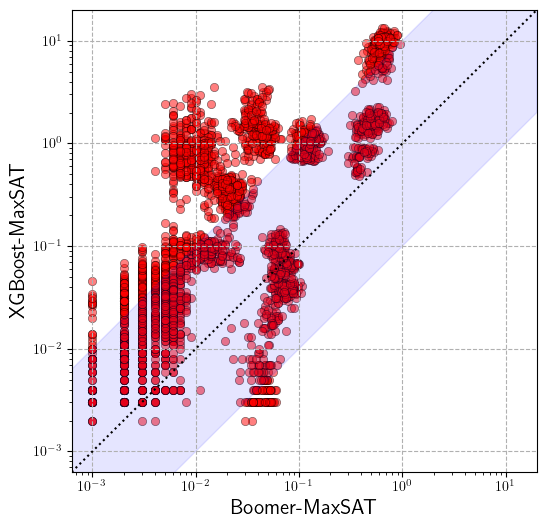

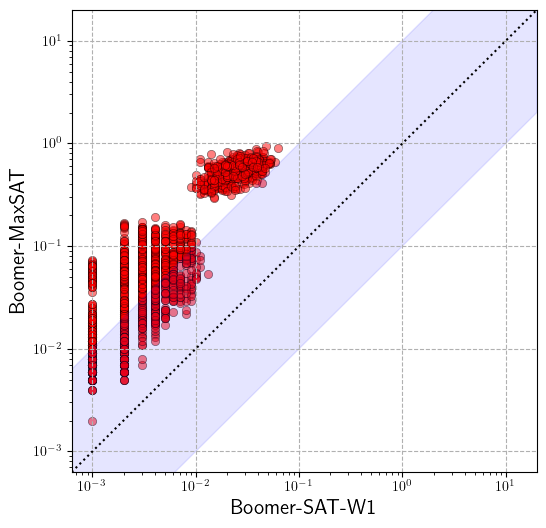

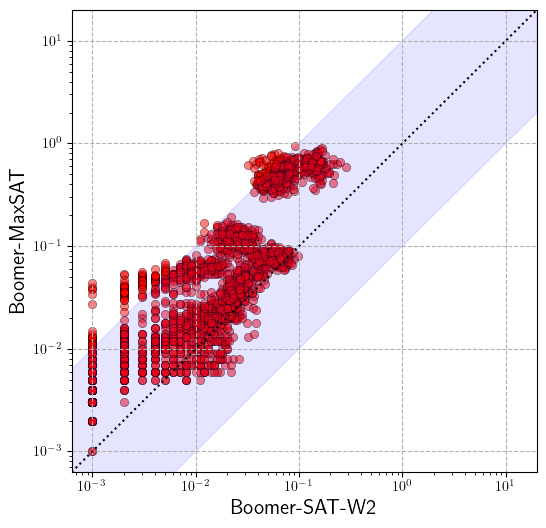

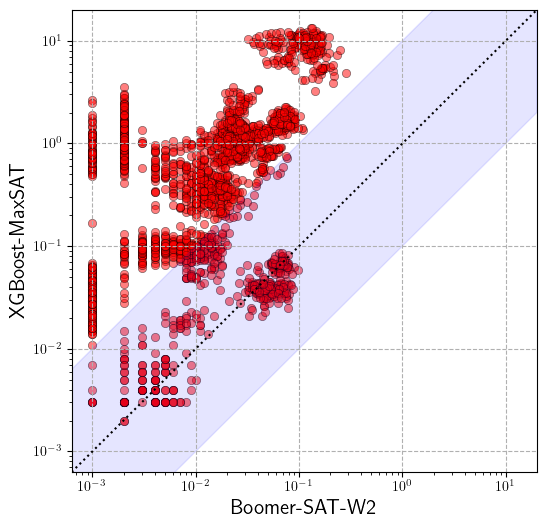

In [28]:
# Scatter 1: deatailed runtime comparison in Boomer-MX and XGBoost-MX
pplots_scatter_two_methods(df_x_b_axp_d_filter, ['boomer', 'xgboost'], log_scale=[True, True], col='t', lims=[-3.2, 1.3, -3.2, 1.3], 
                labels=['Boomer-MaxSAT', 'XGBoost-MaxSAT'], name='xmx-bmx.pdf')

# Scatter 2: detailed runtime comparison between Boomer-SAT-W1 and Boomer-MX
pplots_scatter_two_methods(df_b_axp_d_filter_w1, ['sat', 'boomer'], log_scale=[True, True], col='t', lims=[-3.2, 1.3, -3.2, 1.3], 
                labels=['Boomer-SAT-W1', 'Boomer-MaxSAT'], name='bmx-bsatw1.pdf')

# Scatter 3: detailed runtime comparison between Boomer-SAT-W2 and Boomer-MX
pplots_scatter_two_methods(df_b_axp_d_filter_w2, ['sat', 'boomer'], log_scale=[True, True], col='t', lims=[-3.2, 1.3, -3.2, 1.3], 
                labels=['Boomer-SAT-W2', 'Boomer-MaxSAT'], name='bmx-bsatw2.pdf')

# Scatter 4: detailed runtime comparison between Boomer-SAT-W2 and XGBoost-MX
pplots_scatter_two_methods(df_x_b_axp_d_filter_w2, ['sat', 'xgboost'], log_scale=[True, True], col='t', lims=[-3.2, 1.3, -3.2, 1.3], 
                labels=['Boomer-SAT-W2', 'XGBoost-MaxSAT'], name='xmx-bsatw2.pdf')

#### Exp 3: The cases for MNIST benchmarks

- Prediction quality
- Efficiency in extracting AXps with different encodings.

In [4]:
# 260113: considering the results with different weight digits + pb_encoding + encoding => for MNIST
results_boomer_sat_mnist = 'Exp3_BoostRules_MNIST/results_AXp_boomer_sat'
# results_boomer_mx_mnist = 'Exp3_BoostRules_MNIST/results_AXp_boomer_mx'
info_dict = [{'md': 'max_depth', 'num': 'n_estimator', 'wd': 'wd', 'pb': 'pb'}, 'dataset']
# call function to generate the json files
extract_summary_detail_json(results_boomer_sat_mnist, info_dict, timeout=7200.0)
# extract_summary_detail_json(results_boomer_mx_mnist, info_dict)

results_boomer_mxorig_mnist = 'Exp3_BoostRules_MNIST/results_AXp_boomer_orig'
info_dict_orig = [{'md': 'max_depth', 'num': 'n_estimator'}, 'dataset']
extract_summary_detail_json(results_boomer_mxorig_mnist, info_dict_orig, timeout=7200.0)

############
# Step 2: Transform the results in JSON format into pandas format
# df_boomers_mx_mnist= pd.read_json(os.path.join(results_boomer_mx_mnist, 'summary.json'))
df_boomers_sat_mnist = pd.read_json(os.path.join(results_boomer_sat_mnist, 'summary.json'))
# df_boomers_mx_mnist['method'] = 'mx'
df_boomers_sat_mnist['method'] = 'sat'
# df_boomers_mnist = pd.concat([df_boomers_mx_mnist, df_boomers_sat_mnist])

df_boomers_mxorig_mnist = pd.read_json(os.path.join(results_boomer_mxorig_mnist, 'summary.json'))
df_boomers_mxorig_mnist['method'] = 'boomer-mx'

Summary Json for Exp3_BoostRules_MNIST/results_AXp_boomer_sat is stored in Exp3_BoostRules_MNIST/results_AXp_boomer_sat/summary.json
Deatiled for Exp3_BoostRules_MNIST/results_AXp_boomer_sat is stored in Exp3_BoostRules_MNIST/results_AXp_boomer_sat/detail.json
Summary Json for Exp3_BoostRules_MNIST/results_AXp_boomer_orig is stored in Exp3_BoostRules_MNIST/results_AXp_boomer_orig/summary.json
Deatiled for Exp3_BoostRules_MNIST/results_AXp_boomer_orig is stored in Exp3_BoostRules_MNIST/results_AXp_boomer_orig/detail.json


In [10]:
# 260119: preparing the results for XGBoost in MNIST
results_xgboost_mnist = 'Exp3_BoostRules_MNIST/results_AXp_xgboost_260116'
info_dict = [{'md': 'max_depth', 'num': 'n_estimator'}, 'dataset']
# call function to generate the json files
extract_summary_detail_json(results_xgboost_mnist, info_dict, timeout=7200.0)

######
df_xgboost_mx_mnist = pd.read_json(os.path.join(results_xgboost_mnist, 'summary.json'))
df_xgboost_mx_mnist['method'] = 'xgboost-mx'

# 260305: for xgboost-sat
results_xgboost_sat_mnist = 'Exp3_BoostRules_MNIST/results_AXp_xgboost_sat'
info_dict = [{'md': 'max_depth', 'num': 'n_estimator', 'wd': 'wd', 'pb': 'pb'}, 'dataset']
# call function to generate the json files
extract_summary_detail_json(results_xgboost_sat_mnist, info_dict, timeout=7200.0)

######
df_xgboost_sat_mnist = pd.read_json(os.path.join(results_xgboost_sat_mnist, 'summary.json'))
df_xgboost_sat_mnist['method'] = 'xgboost-sat'

Summary Json for Exp3_BoostRules_MNIST/results_AXp_xgboost_260116 is stored in Exp3_BoostRules_MNIST/results_AXp_xgboost_260116/summary.json
Deatiled for Exp3_BoostRules_MNIST/results_AXp_xgboost_260116 is stored in Exp3_BoostRules_MNIST/results_AXp_xgboost_260116/detail.json
Summary Json for Exp3_BoostRules_MNIST/results_AXp_xgboost_sat is stored in Exp3_BoostRules_MNIST/results_AXp_xgboost_sat/summary.json
Deatiled for Exp3_BoostRules_MNIST/results_AXp_xgboost_sat is stored in Exp3_BoostRules_MNIST/results_AXp_xgboost_sat/detail.json


##### Preparing Tables (Boomer-SAT v.s. Boomer-MaxSAT) with different weight digits.

- One Table corresponds to a specific benchmark with all different maximum depths and number of estimators of methods to explain 200 instances.
- 1st col -> Bench (md, num); 2nd col -> weight digits; cols in Boomer-SAT (Vars, clause, clause_processed, max, min, avg time, avg_calls); cols in Boomer-MaxSAT

In [ ]:
## 260112: Changed code to prepare tables comparing Boomers with different encodings! (SAT/MaxSAT)
# preparing the Tables for all bench
# ptable_boomer_methods_wd(df_boomers_mnist, out_base_path='Exp3_BoostRules_MNIST/tex_table')

##### Preparing single Tables (XGBoost-MaxSAT) + (Boomer-MaxSAT).

In [7]:
def ptable_single_method(df, method, cols_selected, out_base_path='latex_separ', wd=None):
    '''
        prepare table of single method
    '''
    if not os.path.exists(out_base_path):
        os.mkdir(out_base_path)
    datasets = sorted(set(df['dataset']))
    
    for d in datasets:
        # One d corrsponds to a separate Table
        if wd is None:
            out_path = os.path.join(out_base_path, d.replace('\n', '') + '_' + method + '_separ.tex')
        else:
            out_path = os.path.join(out_base_path, d.replace('\n', '') + '_' + method + '_w' + str(wd) + '_separ.tex')
        
        num_estimators = sorted(set(df['n_estimator']))
        m_depths = sorted(set(df['max_depth']))

        with builtins.open(out_path, 'w') as f:
            for md in m_depths:
                for num in num_estimators:
                    if wd is None:
                        df_info = get_df_infos(df, method, md, num, d)
                    else:
                        df_info = get_df_infos(df, method, md, num, d, wd)
                        
                    if df_info.shape[0] == 1: 
                        f.write(d + '(' + str(md) + ', ' + str(num) + ') & ')
                        str_row = str_show_cols(df_info, cols_selected)
                        f.write(str_row + '\n')
                f.write('\\hline \n')


In [11]:
cols_xgboost = ['vars', 'clauses', 'max time', 'min time', 'avg time', 'num time']
ptable_single_method(df_xgboost_mx_mnist, 'xgboost-mx', cols_xgboost, out_base_path='Exp3_BoostRules_MNIST/tex_table')\

cols_xgboost_sat = ['avg vars', 'avg cps', 'max time', 'min time', 'avg time', 'num time']
ptable_single_method(df_xgboost_sat_mnist, 'xgboost-sat', cols_xgboost_sat, out_base_path='Exp3_BoostRules_MNIST/tex_table', wd=1)
ptable_single_method(df_xgboost_sat_mnist, 'xgboost-sat', cols_xgboost_sat, out_base_path='Exp3_BoostRules_MNIST/tex_table', wd=2)

In [17]:
cols_boomer = ['avg vars', 'avg cps', 'max time', 'min time', 'avg time', 'num time']
ptable_single_method(df_boomers_mxorig_mnist, 'boomer-mx', cols_boomer, out_base_path='Exp3_BoostRules_MNIST/tex_table')
ptable_single_method(df_boomers_sat_mnist, 'sat', cols_boomer, out_base_path='Exp3_BoostRules_MNIST/tex_table', wd=1)
ptable_single_method(df_boomers_sat_mnist, 'sat', cols_boomer, out_base_path='Exp3_BoostRules_MNIST/tex_table', wd=2)


#### Preparing plots in Exp 3:

- The cactus plot of showing the CPU time of different methods (Boomer-MaxSAT, Boomer-SAT, XGBoost-MaxSAT) of all instances explained.
- The detailed runtime results are in details.json in each results folder, need to load them then filter them.

In [15]:
results_boomer_sat_mnist = 'Exp3_BoostRules_MNIST/results_AXp_boomer_sat'
results_boomer_mxorig_mnist = 'Exp3_BoostRules_MNIST/results_AXp_boomer_orig'
results_xgboost_mnist = 'Exp3_BoostRules_MNIST/results_AXp_xgboost_260116'
results_xgboost_sat_mnist = 'Exp3_BoostRules_MNIST/results_AXp_xgboost_sat'

df_b_sat_mnist_axp_d = pd.read_json(os.path.join(results_boomer_sat_mnist, 'detail.json'))
df_b_sat_mnist_axp_d['method'] = 'Boomer-SAT'
df_b_mxorig_mnist_axp_d = pd.read_json(os.path.join(results_boomer_mxorig_mnist, 'detail.json'))
df_b_mxorig_mnist_axp_d['method'] = 'Boomer-MaxSAT'
df_x_mx_mnist_axp_d = pd.read_json(os.path.join(results_xgboost_mnist, 'detail.json'))
df_x_mx_mnist_axp_d['method'] = 'XGBoost-MaxSAT'
df_x_sat_mnist_axp_d = pd.read_json(os.path.join(results_xgboost_sat_mnist, 'detail.json'))
df_x_sat_mnist_axp_d['method'] = 'XGBoost-SAT'
df_all_mnist_axp_d = pd.concat([df_b_sat_mnist_axp_d, df_b_mxorig_mnist_axp_d, df_x_mx_mnist_axp_d, df_x_sat_mnist_axp_d])

# forcing the wd and pb as INT
df_all_mnist_axp_d['wd'] = df_all_mnist_axp_d['wd'].astype('Int64')
df_all_mnist_axp_d['pb'] = df_all_mnist_axp_d['pb'].astype('Int64')

# Step 1: filtering selected pairs of presenting the results (test_acc > 0.95) for MNIST!!
# extra requirement:  path <= 20K
# b_d_pair_mnist = [(6, 1000), (6, 1500), (4, 1500), (5, 1500), (6, 2000), (4, 2000), (5, 2000)]
# x_d_pair_mnist = [(4, 40), (4, 50), (5, 30), (4, 60), (4, 70), (6, 20), (5, 40), (4, 80), (4, 90), (4, 100), (6, 30)]

# extra requirement: 10K <= path <= 20K
b_d_pair_mnist = [(4, 1500), (5, 1500), (6, 1500), (4, 2000), (5, 2000), (6, 2000)]
x_d_pair_mnist = [(4, 70), (4, 80), (4, 90), (4, 100), (5, 40), (6, 20), (6, 30)]
b_d_pair_mnist_wd = [(4, 1500, 1), (4, 1500, 2), (5, 1500, 1), (5, 1500, 2), (6, 1500, 1), (6, 1500, 2),
                     (4, 2000, 1), (4, 2000, 2), (5, 2000, 1), (5, 2000, 2), (6, 2000, 1), (6, 2000, 2)]
x_d_pair_mnist_wd = [(4, 70, 1), (4, 80, 1), (4, 90, 1), (4, 100, 1), (5, 40, 1), (6, 20, 1), (6, 30, 1),
                     (4, 70, 2), (4, 80, 2), (4, 90, 2), (4, 100, 2), (5, 40, 2), (6, 20, 2), (6, 30, 2)]
info_dict_orig = {'XGBoost-MaxSAT': x_d_pair_mnist, 'Boomer-MaxSAT': b_d_pair_mnist, 'Boomer-SAT': b_d_pair_mnist_wd, 'XGBoost-SAT': x_d_pair_mnist_wd}

# 260303: select representative ones.
x_d_pair_mnist_r = [(4, 70), (5, 40), (4, 90), (6, 30)]
b_d_pair_mnist_r = [(5, 1500), (5, 2000)]
b_d_pair_mnist_wd_r = [(5, 1500, 1), (5, 1500, 2), (5, 2000, 1), (5, 2000, 2)]
x_d_pair_mnist_wd_r = [(4, 70, 1), (5, 40, 1), (4, 90, 1), (6, 30, 1)]
info_dict_r = {'XGBoost-MaxSAT': x_d_pair_mnist_r, 'Boomer-MaxSAT': b_d_pair_mnist_r, 'Boomer-SAT': b_d_pair_mnist_wd_r}


In [ ]:
# 260306: generate the json files for using mkplot
def gen_json_mkplot(df, info_dict, base_path, timeout=[7200.0, 7200.0], all_orig=100):
    
    for m, v_list in info_dict.items():
        for v in v_list:
            # a single (method, value) pair for the extracting the runtime information
            if m.endswith('-SAT'):
                assert len(v) == 3
                df_info = get_df_infos(df, m, v[0], v[1], dataset='mnist_train', wd=v[2])
                label = m + '-W' + str(v[2]) + '(' + str(v[0]) + ', ' + str(v[1]) + ')'
                tl = timeout[0]
            else:
                assert len(v) == 2
                df_info = get_df_infos(df, m, v[0], v[1], dataset='mnist_train')
                label = m + '(' + str(v[0]) + ', ' + str(v[1]) + ')'
                tl = timeout[-1]
            method_dict = {'stats': {}, 'preamble': {'benchmark': 'mnist_train', 'prog_args': None}}
            method_dict['preamble']['program'] = label

            t = sorted(df_info['t'])
            for i in range(len(t)):
                instance_t = {}
                if t[i] <= tl:
                    instance_t['status'] = True
                    instance_t['rtime'] = t[i]
                else:
                    instance_t['status'] = False
                    instance_t['rtime'] = tl
                method_dict['stats']['instance_' + str(i)] = instance_t
            if len(t) < all_orig:
                for i in range(all_orig - len(t)):
                    instance_t = {'status': False, 'rtime': tl}
                    method_dict['stats']['instance_' + str(len(t) + i)] = instance_t

            if not os.path.isdir(base_path):
                os.mkdir(base_path)
            json_p = os.path.join(base_path, label + '.json')
            if os.path.isfile(json_p):
                os.remove(json_p)
            with open(json_p, 'w') as f:
                json.dump(method_dict, f, indent=4)

gen_json_mkplot(df_all_mnist_axp_d, info_dict_orig, './Exp3_BoostRules_MNIST/results_AXp_JSON_7200')

In [ ]:
# preparing the cactus plots for selected dataframe
def pplots_cactus_mnist(df, info_dict, ylims, col='t', log_yscale=False, axis_t=None, markers={'XGBoost-MaxSAT': 'o', 'Boomer-MaxSAT': 'D', 'Boomer-SAT': ['s', '^']}):
    '''
        col: the col selected as the y-axis, the default is 't' as the running time
        => here reverse the x and y axis
        info_dict: m = 'boomer-sat', there are three values!
    '''
    assert len(ylims) == 2
    plt.figure(figsize=(15, 12))
    plt.grid(True, linestyle='--')
    if log_yscale:
        plt.yscale('log', base=10)
        ylims[0] = 10 ** ylims[0]
        ylims[1] = 10 ** ylims[1]   
    plt.ylim(ylims[0], ylims[1])

    if not axis_t is None:
        assert len(axis_t) == 2
        plt.xlabel(axis_t[0], fontsize=15)
        plt.ylabel(axis_t[-1], fontsize=15) 
    
    for m, v_list in info_dict.items():
        for v in v_list:
            if m == 'Boomer-SAT':
                assert len(v) == 3
                df_info = get_df_infos(df, m, v[0], v[1], dataset='mnist_train', wd=v[2])
                label = m + '-W' + str(v[2]) + '(' + str(v[0]) + ', ' + str(v[1]) + ')'
            else:
                assert len(v) == 2
                df_info = get_df_infos(df, m, v[0], v[1], dataset='mnist_train')
                label = m + '(' + str(v[0]) + ', ' + str(v[1]) + ')'
        
            num_instance = df_info.shape[0]
            # the catcus considers the y-axis as the accumulate time
            # time = list(accumulate(df_info['t']))
            time = sorted(df_info['t'])
            
            if m == 'Boomer-SAT':
                plt.plot(list(range(1, num_instance+1)), time, label=label, marker=markers[m][v[2]-1], markerfacecolor='none')
            elif m.startswith('Boomer'):
                plt.plot(list(range(1, num_instance+1)), time, label=label, marker=markers[m], markerfacecolor='none')
            else:
                plt.plot(list(range(1, num_instance+1)), time, label=label, marker=markers[m])
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.show()

# Catcus plost for all methods
pplots_cactus_mnist(df_all_mnist_axp_d, info_dict_orig, ylims=[0.9, 4], log_yscale=True, axis_t=['Solved Instances', 'CPU Time in Seconds'])
pplots_cactus_mnist(df_all_mnist_axp_d, info_dict_orig, ylims=[0, 7200], log_yscale=False, axis_t=['Solved Instances', 'CPU Time in Seconds'])

# the selected version 
pplots_cactus_mnist(df_all_mnist_axp_d, info_dict_r, ylims=[0.9, 4], log_yscale=True, axis_t=['Solved Instances', 'CPU Time in Seconds'])
pplots_cactus_mnist(df_all_mnist_axp_d, info_dict_r, ylims=[0, 7200], log_yscale=False, axis_t=['Solved Instances', 'CPU Time in Seconds'])


In [17]:
## 260419: get the average length of AXps for pair
def get_avg_len_AXp(df, info_dict):
    '''
        return the dict of corresponding avg_length, where key is the method, value is the list of corresponding parameter list
    '''
    avg_len_axp_dict = {}
    for m, v_list in info_dict.items():
        avg_len_list = []
        for v in v_list:
            if m.endswith('-SAT'):
                assert len(v) == 3
                df_info = get_df_infos(df, m, v[0], v[1], dataset='mnist_train', wd=v[2])
            else:
                assert len(v) == 2
                df_info = get_df_infos(df, m, v[0], v[1], dataset='mnist_train')

            len_axp = list(df_info['s'])
            # print(m, v, len(len_axp))
            avg_len_list.append(sum(len_axp) / len(len_axp))

        avg_len_axp_dict[m] = avg_len_list
    return avg_len_axp_dict

dict_len_axp = get_avg_len_AXp(df_all_mnist_axp_d, info_dict_orig)
for i, v in dict_len_axp.items():
    print(i)
    for id in range(len(info_dict_orig[i])):
        print(info_dict_orig[i][id], dict_len_axp[i][id])


XGBoost-MaxSAT
(4, 70) 275.75
(4, 80) 287.26
(4, 90) 292.04
(4, 100) 299.5217391304348
(5, 40) 245.49
(6, 20) 193.23
(6, 30) 237.6206896551724
Boomer-MaxSAT
(4, 1500) 521.13
(5, 1500) 516.0
(6, 1500) 508.91
(4, 2000) 546.69
(5, 2000) 544.1076923076923
(6, 2000) 532.1641791044776
Boomer-SAT
(4, 1500, 1) 440.67
(4, 1500, 2) 524.9166666666666
(5, 1500, 1) 447.91
(5, 1500, 2) 517.18
(6, 1500, 1) 449.2
(6, 1500, 2) 511.31
(4, 2000, 1) 464.86
(4, 2000, 2) 547.8681318681319
(5, 2000, 1) 470.1
(5, 2000, 2) 541.969696969697
(6, 2000, 1) 469.4
(6, 2000, 2) 530.6666666666666
XGBoost-SAT
(4, 70, 1) 269.29
(4, 80, 1) 279.02
(4, 90, 1) 285.92929292929296
(4, 100, 1) 290.63
(5, 40, 1) 240.95
(6, 20, 1) 189.33
(6, 30, 1) 226.52
(4, 70, 2) 289.8095238095238
(4, 80, 2) 328.3333333333333
(4, 90, 2) 354.5
(4, 100, 2) 329.0
(5, 40, 2) 260.75
(6, 20, 2) 199.8235294117647
(6, 30, 2) 245.94736842105263
